# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer: 1882404
- Naam: Myla Berger
- Datum: 06-03-2026

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [3]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [4]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.403525,0.541004,0.231631,1.304647,1.506054,5.171289,0.776503,1.453591,0.324207,1.420055,0.982749,0.937059,1.454958,1.238607,0.653424,"""Romance (3rd person)"""
1.597639,0.906135,1.05043,1.33866,0.329611,5.434933,0.958579,0.646672,0.483293,1.695583,0.255899,0.579056,1.386561,0.980903,0.567433,"""Romance (1st person)"""
1.310425,0.937092,1.055541,1.109011,0.70207,3.793066,0.122211,2.812553,1.164479,0.776713,0.800708,1.327549,0.365186,0.795637,0.327084,"""Fantasy (1st person)"""
0.737828,1.056646,1.388772,0.839168,0.41934,3.266756,1.273089,1.835885,1.242511,0.291954,1.453167,0.755915,1.771006,0.912067,1.337111,"""Science Fiction (3rd person)"""
0.682039,0.667021,1.029719,0.776543,0.245051,3.27424,1.158594,2.177012,1.439015,0.373844,1.530055,0.9655,1.586618,1.369428,0.998194,"""Science Fiction (3rd person)"""


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.


_0. ($m$, $n$)_<br>
_1. ($n$,)_<br>
_2. ($n$, $n$)_<br>
_3. eigenvectors: ($n$, $n$), eigenvalues: ($n$,)_<br>
_4. ($n$, $n^\prime$)_<br>
_5. ($m$, $n^\prime$)_<br>

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [5]:
def compute_pca(X, n_components):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)

    mean = np.mean(arr, axis=0)
    arr_centered = arr - mean

    # calculate covariant matrix
    cov_matrix = np.cov(arr_centered, rowvar=False)

    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort biggest eigenvalues
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    # Select eigenvectors corresponding biggest eigenvalues
    n_eigenvectors = eigenvectors[:, :n_components]

    # Project the data onto the selected principal components
    return arr_centered @ n_eigenvectors

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [6]:
np.random.seed(1)
X = np.random.rand(3, 10)
X_reduced = compute_pca(X, n_components=2)
print(X_reduced)

[[ 0.434  0.498]
 [ 0.421 -0.504]
 [-0.855  0.005]]


### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

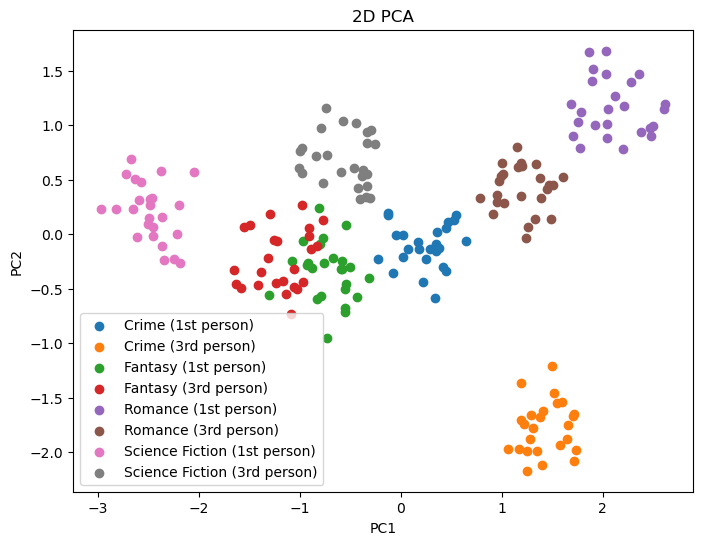

In [7]:
# Format data
columns = data.columns
X = data.select(columns[:-1]).to_numpy()
y = data.select(columns[-1]).to_numpy().ravel()

# apply pca
X_2D = compute_pca(X, n_components=2)

# plot
plt.figure(figsize=(8,6))
for label in np.unique(y):
    plt.scatter(X_2D[y == label, 0], X_2D[y == label, 1], label=label)

# Labels
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA')
plt.legend()
plt.show()

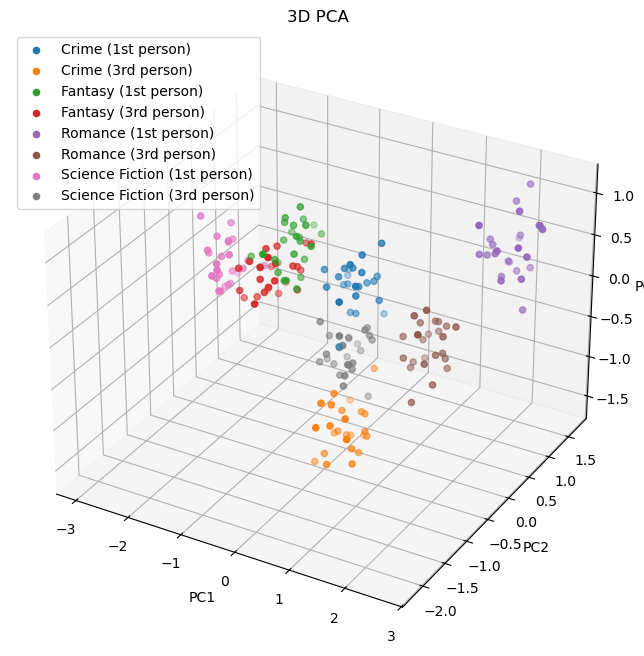

In [8]:
# apply pca
X_3D = compute_pca(X, n_components=3)

# plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
for label in np.unique(y):
    mask = (y == label)
    ax.scatter(X_3D[mask, 0], X_3D[mask, 1], X_3D[mask, 2], label=label)

# Labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA')
ax.legend()
plt.show()

### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 
2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.
3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

_1. Romance (1st) person is het duidelijkst te onderscheiden, Romance (3rd person) is ook nog wel duidelijk te onderscheiden en crime (1st en 3rd) beide ook nog redelijk, al wel wat minder duidelijk. Fantasy (beide 1st en 3rd person) liggen erg dicht op elkaar en lijken vrijwel dezelfde cluster, ook lijkt science fiction (1st person) hier wat in te mixen._ <br>

_De antwoorden voor 2, 3 & 4 bereken ik op basis van de eigenwaarden._

In [15]:
# calculate covariant matrix
mean = np.mean(X, axis=0)
X_centered = X - mean
cov_matrix = np.cov(X_centered, rowvar=False)
eigenvalues, _ = np.linalg.eigh(cov_matrix)

# Sort on biggest
eigenvalues = np.sort(eigenvalues)[::-1]

# calculate percentages
total_variance = np.sum(eigenvalues)
var_per_comp = (eigenvalues / total_variance) * 100
cumsum_var = np.cumsum(var_per_comp)

# Print results
print(f"2. 2D behoud: {cumsum_var[1]:.2f}%\t3D behoud: {cumsum_var[2]:.2f}%")
print(f"3. 90% behoud bij: {np.argmax(cumsum_var >= 90) + 1} dimensies")
print(f"4. 95% behoud bij: {np.argmax(cumsum_var >= 95) + 1} dimensies")

2. 2D behoud: 68.67%	3D behoud: 77.22%
3. 90% behoud bij: 7 dimensies
4. 95% behoud bij: 11 dimensies


## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien). 

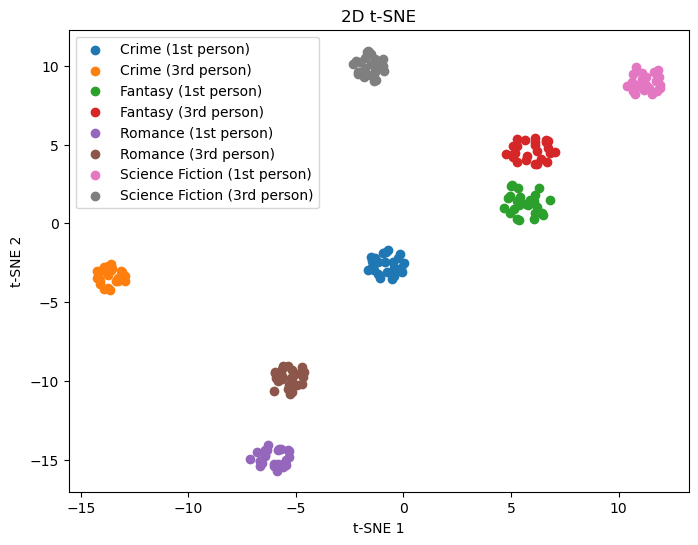

In [9]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_2D = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(8,6))
for label in np.unique(y):
    plt.scatter(X_2D[y == label, 0], X_2D[y == label, 1], label=label)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('2D t-SNE')
plt.legend()
plt.show()

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?
2. Hoe verhouden de algoritmes zich in het behoud van informatie?

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

_1. In t-SNE zijn de clusters duidelijker te onderscheiden van elkaar tegenover PCA, waarbij er veel overlap aanwezig is tussen de verschillende categorieën. t-SNE slaagt erin om de grenzen tussen genres scherp te trekken, terwijl PCA de data als een meer doorlopend geheel laat zien._ <br><br>
_2. PCA reduceert naar 2 of 3 dimensies op basis van een lineaire correlatie, dit zorgt er echter voor dat er informatie uit bepaalde features verloren gaan waardoor de datapunten rommelig verspreid zijn. t-SNE pakt dit beter aan, waardoor er hele duidelijke clusters zichtbaar zijn, maar omdat dit op basis gaat van soortgelijke datapunten naar elkaar toe trekken, kunnen de afstanden tussen datapunten mogelijk minder zeggen._<br><br>
_3. PCA en t-SNE kunnen ingezet worden om data met hoge dimensionaliteit te verkennen door middel van een visualisatie die deze dimensies plat slaat naar een begrijpelijker formaat. Dit is handig om bepaalde patronen, clusters of outliers te herkennen._ <br><br>
_4. PCA heeft voorkeur bij data met lineaire correlaties. Bijvoorbeeld bij meetgegevens, waarbij er sprake is van een lineaire samenhanging._<br><br>
_5. t-SNE heeft voorkeur bij complexere data waarbij er juist geen lineaire structuren aanwezig zijn. Een goed voorbeeld hiervoor zijn afbeeldingen, waarbij er vergelijkbare beelden samen geclusterd kunnen worden._ <br><br>

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

_1. We werken met foto's (IMG), dus de dimensionaliteit is afhankelijk van het aantal pixels in een afbeelding. Hierbij spreken we van de hoogte x breedte x RGB (indien van toepassing) zijn. Dit betekent dus dat een afbeelding met bijvoorbeeld 224 × 224 pixels al 150.528 features bevat. Hierdoor is er sprake van hoge dimensionaliteit, wat het analyseren en visualiseren van de data moeilijk maakt._ <br><br>
_2. Dimensionaliteits reductie zou ons kunnen helpen met de data verkennen, t-NSE heeft hierbij meer potentie dan pca, omdat ik niet direct duidelijke lineaire verbanden verwacht in foto's van meterkasten. Er zou gebruik gemaakt kunnen worden van t-SNE, omdat er mogelijk clustervormingen kunnen bestaan bij specifieke kenmerken die terugkomen in afbeeldingen._